# Model Improvements

**Standalone notebook.** Requires only `data_for_experiments`.

| # | Improvement | Hypothesis |
|---|---|---|
| 1 | SHAP-guided feature re-selection | SHAP top-30 outperforms MDI top-30 |
| 2 | Stablecoin removal | Cleaner universe improves signal quality |
| 3 | Label threshold tuning | Tighter/wider extremes affect signal purity |
| 4 | Walk-forward validation | Rolling retraining reflects real trading |
| 5 | SMOTE class imbalance | Better recall on extreme buckets |
| 6 | Return-ranked target | Raw return vs Sharpe as label target |
| 7 | Confidence-weighted positions | Probability-weighted sizing improves long leg |

**Baseline:** MDI top-30, XGBoost, static split, equal weights, Sharpe target, all coins.

In [ ]:
from __future__ import annotations
from pathlib import Path
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from xgboost import XGBClassifier
try:
    from imblearn.combine import SMOTEENN
    HAS_IMBALANCED = True
except ImportError:
    HAS_IMBALANCED = False
    print('imbalanced-learn not installed — Improvement 5 will be skipped.')
    print('Install with: pip install imbalanced-learn')
warnings.filterwarnings('ignore')

IN_FILE = Path('Models/Data/data_for_experiments.csv')
OUT_DIR = Path('Models/Figures')

TRAIN_CUTOFF = '2024-01'
FORWARD_DAYS = 7
MIN_COINS    = 20
TOP_N        = 30

LABEL_ORDER  = ['Strong Avoid', 'Avoid', 'Neutral', 'Buy', 'Strong Buy']
LABEL_MAP    = {'Strong Avoid': 0, 'Avoid': 1, 'Neutral': 2, 'Buy': 3, 'Strong Buy': 4}
BINS_DEFAULT = [0, 0.10, 0.30, 0.70, 0.90, 1.001]
LONG_LABEL   = 'Strong Buy'
SHORT_LABEL  = 'Strong Avoid'
BTC_COLOR    = '#F7931A'

# SHAP top-30 from shap_analysis.ipynb results
SHAP_TOP30 = [
    'coin_age_days', 'atr_14', 'obv', 'return_1d', 'atr_pct',
    'minus_di', 'price_vs_ath', 'return_7d', 'coin_mcap_share_recalc_rank',
    'volume_vs_30d_avg', 'price_vs_atl', 'galaxy_score_zscore', 'volume',
    'return_30d', 'obv_divergence', 'market_cap_usd_zscore', 'plus_di',
    'drawdown_from_90d_peak', 'adx', 'stoch_k', 'ema_50_vs_200', 'macd_hist',
    'volatility_30d', 'stoch_d', 'price_vs_ema50', 'bb_pct',
    'price_vs_ema200', 'rsi_14', 'coin_mcap_share_recalc', 'bb_width'
]

LEAKY_COLS = {
    'label', 'forward_return_7d', 'forward_sharpe_7d', 'forward_sharpe_rank',
    'return_1d_rank', 'return_1d_zscore', 'return_7d_rank', 'return_7d_zscore',
    'return_30d_rank', 'return_30d_zscore', 'volatility_30d_rank', 'volatility_30d_zscore',
    'rsi_14_rank', 'rsi_14_zscore', 'macd_hist_rank', 'macd_hist_zscore',
    'bb_pct_rank', 'bb_pct_zscore', 'atr_pct_rank', 'atr_pct_zscore',
    'obv_divergence_rank', 'obv_divergence_zscore', 'stoch_k_rank', 'stoch_k_zscore',
    'adx_rank', 'adx_zscore', 'volume_vs_30d_avg_rank', 'volume_vs_30d_avg_zscore',
    'drawdown_from_90d_peak_rank', 'drawdown_from_90d_peak_zscore',
    'price_vs_ath_rank', 'price_vs_ath_zscore', 'range_position_30d_rank',
    'range_position_30d_zscore', 'consecutive_up_days_rank', 'consecutive_up_days_zscore',
    'consecutive_down_days_rank', 'consecutive_down_days_zscore',
    'coin_age_days_rank', 'coin_age_days_zscore',
    'momentum_score', 'mean_reversion_score', 'trend_score',
    'asset_id', 'year_week', 'date', 'timestamp', 'exchange',
    'pair_symbol', 'source', 'open', 'high', 'low', 'close',
    'granularity', 'is_active',
}

CS_FEATURES = [
    'return_1d', 'return_7d', 'return_30d', 'volatility_30d',
    'rsi_14', 'macd_hist', 'bb_pct', 'atr_pct', 'obv_divergence',
    'stoch_k', 'adx', 'volume_vs_30d_avg', 'drawdown_from_90d_peak',
    'price_vs_ath', 'range_position_30d', 'consecutive_up_days',
    'consecutive_down_days', 'coin_age_days', 'galaxy_score', 'alt_rank',
    'market_cap_usd', 'coin_mcap_share_recalc', 'oi_usd', 'funding_rate',
    'taker_buy_ratio',
]

XGB_PARAMS = dict(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', verbosity=0,
    random_state=42, n_jobs=-1
)

def prep(d, cols):
    available = [c for c in cols if c in d.columns]
    return d[available].fillna(0).replace([np.inf, -np.inf], 0).clip(-1e9, 1e9)

def cumret(s):
    return (1 + pd.Series(s).fillna(0)).cumprod()

ALL_RESULTS = []
print('Config loaded.')

Config loaded.


## 1. Load data — compute forward metrics on DAILY rows

**Key fix:** `forward_return_7d` and `forward_sharpe_7d` are computed here on the
raw daily OHLCV data before taking weekly snapshots. If you compute them after
`.groupby().last()`, a shift of 7 means 7 *weeks* ahead, producing returns of
thousands of percent.

In [ ]:
df = pd.read_csv(IN_FILE, low_memory=False)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['asset_id', 'date']).reset_index(drop=True)
df['year_week'] = df['date'].dt.strftime('%G-W%V')
print(f'Loaded: {df.shape[0]:,} rows | {df["asset_id"].nunique()} coins')

def compute_forward_sharpe_7d(group):
    closes, results = group['close'].values, []
    for i in range(len(closes)):
        end = i + FORWARD_DAYS
        if end >= len(closes):
            results.append(np.nan); continue
        window     = closes[i:end]
        daily_rets = np.diff(window) / window[:-1]
        fwd_ret    = (window[-1] - window[0]) / window[0]
        vol        = daily_rets.std() * np.sqrt(365)
        results.append((fwd_ret / vol) if vol > 1e-8 else 0.0)
    return pd.Series(results, index=group.index)

def compute_forward_return_7d(group):
    closes, results = group['close'].values, []
    for i in range(len(closes)):
        end = i + FORWARD_DAYS
        if end >= len(closes):
            results.append(np.nan); continue
        results.append((closes[end] - closes[i]) / closes[i])
    return pd.Series(results, index=group.index)
df['forward_return_7d'] = df.groupby('asset_id')['close'].transform(
    lambda x: x.shift(-FORWARD_DAYS) / x - 1)

fr = df['forward_return_7d'].dropna()
print(f'forward_return_7d: mean={fr.mean()*100:.2f}%  '
      f'p1={fr.quantile(0.01)*100:.1f}%  p99={fr.quantile(0.99)*100:.1f}%')
if fr.abs().max() > 50:
    raise ValueError('forward_return_7d > 5000% — something is wrong with computation order')
print('Sanity check passed.')

Loaded: 211,498 rows | 164 coins
forward_return_7d: mean=0.83%  p1=-32.8%  p99=59.5%
Sanity check passed.


## 2. Pipeline functions

In [4]:
def build_weekly_snapshots(data):
    """Last daily row per (asset, week). Forward metrics already attached to daily rows."""
    w = (
        data.dropna(subset=['forward_sharpe_7d'])
        .sort_values('date')
        .groupby(['asset_id', 'year_week']).last()
        .reset_index()
    )
    if 'year_week' not in w.columns:
        w['year_week'] = pd.to_datetime(w['date']).dt.strftime('%G-W%V')
    return w

def label_snapshots(snaps, bins=BINS_DEFAULT, target='forward_sharpe_7d'):
    def _assign(group):
        if len(group) < MIN_COINS:
            return group.assign(label=np.nan)
        q = group[target].rank(pct=True)
        g = group.copy()
        g['label'] = pd.cut(q, bins=bins, labels=LABEL_ORDER, include_lowest=True)
        return g
    labeled = (
        snaps.groupby('year_week', group_keys=False).apply(_assign)
        .dropna(subset=['label']).reset_index(drop=True)
    )
    if 'year_week' not in labeled.columns:
        labeled['year_week'] = pd.to_datetime(labeled['date']).dt.strftime('%G-W%V')
    return labeled

def add_cs_features(w):
    if 'year_week' not in w.columns:
        w['year_week'] = pd.to_datetime(w['date']).dt.strftime('%G-W%V')
    for col in [c for c in CS_FEATURES if c in w.columns]:
        w[f'{col}_rank']   = w.groupby('year_week')[col].transform(lambda x: x.rank(pct=True))
        w[f'{col}_zscore'] = w.groupby('year_week')[col].transform(
            lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))
    return w

def split_and_features(weekly):
    w      = add_cs_features(weekly.copy())
    cutoff = pd.Timestamp(TRAIN_CUTOFF + '-01')
    tr     = w[pd.to_datetime(w['date']) <  cutoff].copy()
    te     = w[pd.to_datetime(w['date']) >= cutoff].copy()
    feats  = [
        c for c in w.columns
        if c not in LEAKY_COLS
        and w[c].dtype in [np.float64, np.float32, np.int64, np.int32]
    ]
    null_r = tr[feats].isnull().mean()
    feats  = [f for f in feats if null_r[f] <= 0.30]
    return tr, te, feats, tr['label'].map(LABEL_MAP), te['label'].map(LABEL_MAP)

def select_mdi_top30(tr, feats, y_tr):
    rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                 max_features='sqrt', class_weight='balanced',
                                 oob_score=True, n_jobs=-1, random_state=42)
    rf.fit(prep(tr, feats), y_tr)
    imp = pd.Series(rf.feature_importances_, index=feats).sort_values(ascending=False)
    print(f'  RF OOB: {rf.oob_score_*100:.2f}%')
    return imp.head(TOP_N).index.tolist()

def train_xgb(tr, te, feats, y_tr, y_te, label='XGBoost'):
    t0  = time.time()
    clf = XGBClassifier(**XGB_PARAMS)
    clf.fit(prep(tr, feats), y_tr)
    pred = clf.predict(prep(te, feats))
    acc  = accuracy_score(y_te, pred)
    f1   = f1_score(y_te, pred, average='macro')
    print(f'  {label}: acc={acc*100:.2f}%  F1={f1*100:.2f}%  ({time.time()-t0:.1f}s)')
    return clf, pred, acc, f1

def compute_pnl(pred_array, df_te):
    labels = pd.Series([LABEL_ORDER[p] for p in pred_array], index=df_te.index)
    rows   = []
    for wk in sorted(df_te['year_week'].unique()):
        m  = df_te[df_te['year_week'] == wk]
        l  = labels[m.index]
        lr = m[l == LONG_LABEL]['forward_return_7d'].median()
        sr = m[l == SHORT_LABEL]['forward_return_7d'].median()
        rows.append({
            'week': wk,
            'long':  lr if pd.notna(lr) else 0.0,
            'short': sr if pd.notna(sr) else 0.0,
            'net':   (lr - sr) if (pd.notna(lr) and pd.notna(sr)) else np.nan,
        })
    return pd.DataFrame(rows).set_index('week')

def strategy_stats(pred_array, df_te, name):
    pnl    = compute_pnl(pred_array, df_te)
    s      = pnl['net'].dropna()
    cum    = cumret(pnl['net']).values[-1]
    avg    = s.mean() * 100
    wr     = (s > 0).mean() * 100
    spread = avg  # avg net = avg spread for L/S
    labels = pd.Series([LABEL_ORDER[p] for p in pred_array], index=df_te.index)
    avgs   = [df_te[labels == lbl]['forward_return_7d'].mean() for lbl in LABEL_ORDER]
    mono   = all(avgs[i] <= avgs[i+1] for i in range(len(avgs)-1)
                 if pd.notna(avgs[i]) and pd.notna(avgs[i+1]))
    print(f'  {name}: spread={spread:+.2f}% | wr={wr:.0f}% | cum={cum:.1f}x | mono={mono}')
    return {
        'Improvement':    name,
        'Avg Spread (%)': round(spread, 2),
        'Win Rate (%)':   round(wr, 1),
        'Cum Return (x)': round(cum, 1),
        'Monotonic':      mono,
        '_pnl':           pnl,
    }

# Pre-build baseline snapshots (reused across improvements)
snaps_all = build_weekly_snapshots(df)
print(f'Base snapshots: {len(snaps_all):,} rows')
print('Pipeline functions ready.')

Base snapshots: 30,107 rows
Pipeline functions ready.


## 3. Baseline

In [ ]:
print('=== BASELINE ===')
weekly_base = label_snapshots(snaps_all, bins=BINS_DEFAULT, target='forward_sharpe_7d')
train_base, test_base, all_features, y_train_base, y_test_base = split_and_features(weekly_base)
print(f'Train: {len(train_base):,} | Test: {len(test_base):,} | Features: {len(all_features)}')

fr = test_base['forward_return_7d'].dropna()
print(f'Test forward_return_7d: mean={fr.mean()*100:.2f}%  p99={fr.quantile(0.99)*100:.1f}%')

mdi_top30 = select_mdi_top30(train_base, all_features, y_train_base)
clf_base, pred_base, acc_base, _ = train_xgb(
    train_base, test_base, mdi_top30, y_train_base, y_test_base, 'Baseline')
row_base = strategy_stats(pred_base, test_base, 'Baseline')
row_base['Accuracy (%)'] = round(acc_base*100, 2)
ALL_RESULTS.append(row_base)

test_start = pd.Timestamp(TRAIN_CUTOFF + '-01')
btc_w = (df[df['asset_id']=='bitcoin'].set_index('date')['close']
         .resample('W').last().pct_change().loc[test_start:])
eth_w = (df[df['asset_id']=='ethereum'].set_index('date')['close']
         .resample('W').last().pct_change().loc[test_start:])

=== BASELINE ===
Train: 15,651 | Test: 14,399 | Features: 103
Test forward_return_7d: mean=0.05%  p99=51.5%
  RF OOB: 28.85%
  Baseline: acc=38.15%  F1=18.94%  (27.5s)
  Baseline: spread=+3.20% | wr=66% | cum=15.5x | mono=True


## 4. Improvement 1 — SHAP features

In [6]:
print('=== IMPROVEMENT 1: SHAP features ===')
shap_feats = [f for f in SHAP_TOP30 if f in all_features]
print(f'  Available: {len(shap_feats)} | Overlap with MDI: {len(set(mdi_top30) & set(shap_feats))}')
clf_shap, pred_shap, acc_shap, _ = train_xgb(
    train_base, test_base, shap_feats, y_train_base, y_test_base, 'SHAP top-30')
row1 = strategy_stats(pred_shap, test_base, 'Imp 1 — SHAP features')
row1['Accuracy (%)'] = round(acc_shap*100, 2)
ALL_RESULTS.append(row1)

=== IMPROVEMENT 1: SHAP features ===
  Available: 30 | Overlap with MDI: 30
  SHAP top-30: acc=37.99%  F1=18.88%  (32.2s)
  Imp 1 — SHAP features: spread=+3.73% | wr=67% | cum=23.8x | mono=False


## 5. Improvement 2 — Stablecoin removal

In [7]:
print('=== IMPROVEMENT 2: Stablecoin removal ===')
stable_ids = set(df[df['is_stable'] == 1]['asset_id'].unique()) if 'is_stable' in df.columns \
             else set(df.groupby('asset_id')['return_1d'].std()[lambda x: x < 0.002].index)
print(f'  Removing {len(stable_ids)} stablecoins')
df_ns      = df[~df['asset_id'].isin(stable_ids)].copy()
snaps_ns   = build_weekly_snapshots(df_ns)
weekly_ns  = label_snapshots(snaps_ns, bins=BINS_DEFAULT, target='forward_sharpe_7d')
tr_ns, te_ns, feats_ns, y_tr_ns, y_te_ns = split_and_features(weekly_ns)
top_ns     = select_mdi_top30(tr_ns, feats_ns, y_tr_ns)
clf_ns, pred_ns, acc_ns, _ = train_xgb(tr_ns, te_ns, top_ns, y_tr_ns, y_te_ns, 'No stablecoins')
row2 = strategy_stats(pred_ns, te_ns, 'Imp 2 — No stablecoins')
row2['Accuracy (%)'] = round(acc_ns*100, 2)
ALL_RESULTS.append(row2)

=== IMPROVEMENT 2: Stablecoin removal ===
  Removing 11 stablecoins
  RF OOB: 28.38%
  No stablecoins: acc=38.02%  F1=16.83%  (29.2s)
  Imp 2 — No stablecoins: spread=+10.16% | wr=73% | cum=91.2x | mono=True


## 6. Improvement 3 — Label threshold tuning

In [8]:
print('=== IMPROVEMENT 3: Label thresholds ===')
for tname, bins in [
    ('Tight 5/95',    [0, 0.05, 0.30, 0.70, 0.95, 1.001]),
    ('Wide 15/85',    [0, 0.15, 0.30, 0.70, 0.85, 1.001]),
    ('Very wide 20/80',[0, 0.20, 0.30, 0.70, 0.80, 1.001]),
]:
    print(f'\n  --- {tname} ---')
    w_t = label_snapshots(snaps_all, bins=bins, target='forward_sharpe_7d')
    tr_t, te_t, feats_t, y_tr_t, y_te_t = split_and_features(w_t)
    top_t = select_mdi_top30(tr_t, feats_t, y_tr_t)
    clf_t, pred_t, acc_t, _ = train_xgb(tr_t, te_t, top_t, y_tr_t, y_te_t, tname)
    row = strategy_stats(pred_t, te_t, f'Imp 3 — {tname}')
    row['Accuracy (%)'] = round(acc_t*100, 2)
    ALL_RESULTS.append(row)

=== IMPROVEMENT 3: Label thresholds ===

  --- Tight 5/95 ---
  RF OOB: 32.92%
  Tight 5/95: acc=36.35%  F1=21.18%  (31.6s)
  Imp 3 — Tight 5/95: spread=+9.71% | wr=59% | cum=4.6x | mono=True

  --- Wide 15/85 ---
  RF OOB: 28.48%
  Wide 15/85: acc=38.84%  F1=18.82%  (29.2s)
  Imp 3 — Wide 15/85: spread=+1.96% | wr=60% | cum=5.2x | mono=False

  --- Very wide 20/80 ---
  RF OOB: 28.69%
  Very wide 20/80: acc=39.43%  F1=18.72%  (32.6s)
  Imp 3 — Very wide 20/80: spread=+1.78% | wr=67% | cum=5.3x | mono=False


## 7. Improvement 4 — Walk-forward validation

In [9]:
print('=== IMPROVEMENT 4: Walk-forward ===')
weekly_wf = add_cs_features(weekly_base.copy())
weekly_wf['date'] = pd.to_datetime(weekly_wf['date'])
wf_parts  = []

for i, q_start in enumerate(pd.date_range('2024-01-01', '2026-03-01', freq='QS')):
    q_end = q_start + pd.DateOffset(months=3)
    tr_q  = weekly_wf[weekly_wf['date'] <  q_start].copy()
    te_q  = weekly_wf[(weekly_wf['date'] >= q_start) & (weekly_wf['date'] < q_end)].copy()
    if len(tr_q) < 500 or len(te_q) < 50: continue
    y_tr_q = tr_q['label'].map(LABEL_MAP).dropna()
    y_te_q = te_q['label'].map(LABEL_MAP).dropna()
    tr_q, te_q = tr_q.loc[y_tr_q.index], te_q.loc[y_te_q.index]
    feats_q = [
        c for c in weekly_wf.columns
        if c not in LEAKY_COLS
        and weekly_wf[c].dtype in [np.float64, np.float32, np.int64, np.int32]
        and tr_q[c].isnull().mean() <= 0.30
    ]
    top_q = select_mdi_top30(tr_q, feats_q, y_tr_q)
    clf_q = XGBClassifier(**XGB_PARAMS)
    clf_q.fit(prep(tr_q, top_q), y_tr_q)
    pred_q = clf_q.predict(prep(te_q, top_q))
    acc_q  = accuracy_score(y_te_q, pred_q)
    print(f'  Q{i+1} ({q_start.date()}→{q_end.date()}): acc={acc_q*100:.2f}%  test={len(te_q):,}')
    te_q = te_q.copy(); te_q['_pred'] = pred_q
    wf_parts.append(te_q)

test_wf  = pd.concat(wf_parts).reset_index(drop=True)
pred_wf  = test_wf['_pred'].values
acc_wf   = accuracy_score(test_wf['label'].map(LABEL_MAP), pred_wf)
print(f'  Overall acc: {acc_wf*100:.2f}%')
row4 = strategy_stats(pred_wf, test_wf, 'Imp 4 — Walk-forward')
row4['Accuracy (%)'] = round(acc_wf*100, 2)
ALL_RESULTS.append(row4)

=== IMPROVEMENT 4: Walk-forward ===
  RF OOB: 28.85%
  Q1 (2024-01-01→2024-04-01): acc=38.60%  test=1,386
  RF OOB: 29.63%
  Q2 (2024-04-01→2024-07-01): acc=37.76%  test=1,454
  RF OOB: 28.69%
  Q3 (2024-07-01→2024-10-01): acc=39.28%  test=1,479
  RF OOB: 29.54%
  Q4 (2024-10-01→2025-01-01): acc=37.84%  test=1,546
  RF OOB: 29.55%
  Q5 (2025-01-01→2025-04-01): acc=39.42%  test=1,682
  RF OOB: 29.90%
  Q6 (2025-04-01→2025-07-01): acc=40.74%  test=1,745
  RF OOB: 30.08%
  Q7 (2025-07-01→2025-10-01): acc=39.38%  test=1,851
  RF OOB: 30.46%
  Q8 (2025-10-01→2026-01-01): acc=39.09%  test=1,980
  RF OOB: 30.49%
  Q9 (2026-01-01→2026-04-01): acc=39.50%  test=1,276
  Overall acc: 39.11%
  Imp 4 — Walk-forward: spread=+6.20% | wr=71% | cum=108.7x | mono=True


## 8. Improvement 5 — SMOTE

In [21]:
print('=== IMPROVEMENT 5: SMOTE ===')
X_sm, y_sm = prep(train_base, mdi_top30).values, y_train_base.values
print(f'  Before: {dict(zip(*np.unique(y_sm, return_counts=True)))}')
try:
    X_r, y_r = SMOTEENN(random_state=42).fit_resample(X_sm, y_sm)
    method = 'SMOTE-ENN'
except Exception:
    from imblearn.over_sampling import SMOTE
    X_r, y_r = SMOTE(random_state=42).fit_resample(X_sm, y_sm)
    method = 'SMOTE'
print(f'  After {method}: {dict(zip(*np.unique(y_r, return_counts=True)))}')
clf_sm = XGBClassifier(**XGB_PARAMS)
clf_sm.fit(X_r, y_r)
pred_sm = clf_sm.predict(prep(test_base, mdi_top30))
acc_sm  = accuracy_score(y_test_base, pred_sm)
print(f'  acc={acc_sm*100:.2f}%')
print(classification_report(y_test_base, pred_sm, target_names=LABEL_ORDER))
row5 = strategy_stats(pred_sm, test_base, f'Imp 5 — {method}')
row5['Accuracy (%)'] = round(acc_sm*100, 2)
ALL_RESULTS.append(row5)

=== IMPROVEMENT 5: SMOTE ===
  Before: {0: 1481, 1: 3108, 2: 6249, 3: 3109, 4: 1704}
  After SMOTE: {0: 6249, 1: 6249, 2: 6249, 3: 6249, 4: 6249}
  acc=32.94%
              precision    recall  f1-score   support

Strong Avoid       0.17      0.22      0.19      1397
       Avoid       0.23      0.12      0.16      2871
     Neutral       0.44      0.62      0.51      5756
         Buy       0.19      0.11      0.14      2871
  Strong Buy       0.16      0.13      0.14      1504

    accuracy                           0.33     14399
   macro avg       0.24      0.24      0.23     14399
weighted avg       0.29      0.33      0.30     14399

  Imp 5 — SMOTE: spread=+1.31% | wr=58% | cum=3.4x | mono=True


## 9. Improvement 6 — Return-ranked target

In [11]:
print('=== IMPROVEMENT 6: Return-ranked target ===')
weekly_ret = label_snapshots(snaps_all, bins=BINS_DEFAULT, target='forward_return_7d')
tr_r, te_r, feats_r, y_tr_r, y_te_r = split_and_features(weekly_ret)
top_r = select_mdi_top30(tr_r, feats_r, y_tr_r)
clf_r, pred_r, acc_r, _ = train_xgb(tr_r, te_r, top_r, y_tr_r, y_te_r, 'Return target')
row6 = strategy_stats(pred_r, te_r, 'Imp 6 — Return target')
row6['Accuracy (%)'] = round(acc_r*100, 2)
ALL_RESULTS.append(row6)

=== IMPROVEMENT 6: Return-ranked target ===
  RF OOB: 33.01%
  Return target: acc=37.82%  F1=21.73%  (30.8s)
  Imp 6 — Return target: spread=+8.26% | wr=66% | cum=589.2x | mono=False


## 10. Improvement 7 — Confidence-weighted sizing

In [12]:
print('=== IMPROVEMENT 7: Confidence-weighted sizing ===')
prob = clf_base.predict_proba(prep(test_base, mdi_top30))
te7  = test_base.copy()
te7['prob_SB'] = prob[:, 4]
te7['prob_SA'] = prob[:, 0]

rows_cw = []
for wk in sorted(te7['year_week'].unique()):
    m  = te7[te7['year_week'] == wk]
    tl = m['prob_SB'].quantile(0.90)
    ts = m['prob_SA'].quantile(0.90)
    lo = m[m['prob_SB'] >= tl]
    sh = m[m['prob_SA'] >= ts]
    wl = lo['prob_SB'] / lo['prob_SB'].sum() if len(lo) else None
    ws = sh['prob_SA'] / sh['prob_SA'].sum() if len(sh) else None
    lr = (lo['forward_return_7d'] * wl).sum() if wl is not None else np.nan
    sr = (sh['forward_return_7d'] * ws).sum() if ws is not None else np.nan
    rows_cw.append({'week': wk, 'long': lr or 0, 'short': sr or 0,
                    'net': (lr-sr) if (pd.notna(lr) and pd.notna(sr)) else np.nan})

pnl_cw = pd.DataFrame(rows_cw).set_index('week')
s_cw   = pnl_cw['net'].dropna()
cum_cw = cumret(pnl_cw['net']).values[-1]
wr_cw  = (s_cw > 0).mean() * 100
sp_cw  = s_cw.mean() * 100
print(f'  Baseline: spread={row_base["Avg Spread (%)"]:.2f}% | cum={row_base["Cum Return (x)"]:.1f}x')
print(f'  Conf wt:  spread={sp_cw:+.2f}% | wr={wr_cw:.0f}% | cum={cum_cw:.1f}x')
ALL_RESULTS.append({
    'Improvement': 'Imp 7 — Confidence weighted',
    'Accuracy (%)': row_base['Accuracy (%)'],
    'Avg Spread (%)': round(sp_cw, 2),
    'Win Rate (%)': round(wr_cw, 1),
    'Cum Return (x)': round(cum_cw, 1),
    'Monotonic': row_base['Monotonic'],
    '_pnl': pnl_cw,
})

=== IMPROVEMENT 7: Confidence-weighted sizing ===
  Baseline: spread=3.20% | cum=15.5x
  Conf wt:  spread=+2.84% | wr=70% | cum=18.4x


## 11. Summary + figures

MODEL IMPROVEMENTS SUMMARY
                Improvement  Accuracy (%)  Avg Spread (%)  Win Rate (%)  Cum Return (x)  Monotonic
                   Baseline         38.15            3.20          66.3            15.5       True
      Imp 1 — SHAP features         37.99            3.73          67.0            23.8      False
     Imp 2 — No stablecoins         38.02           10.16          73.3            91.2       True
         Imp 3 — Tight 5/95         36.35            9.71          58.6             4.6       True
         Imp 3 — Wide 15/85         38.84            1.96          60.4             5.2      False
    Imp 3 — Very wide 20/80         39.43            1.78          67.0             5.3      False
       Imp 4 — Walk-forward         39.11            6.20          70.5           108.7       True
      Imp 6 — Return target         37.82            8.26          66.3           589.2      False
Imp 7 — Confidence weighted         38.15            2.84          69.6           

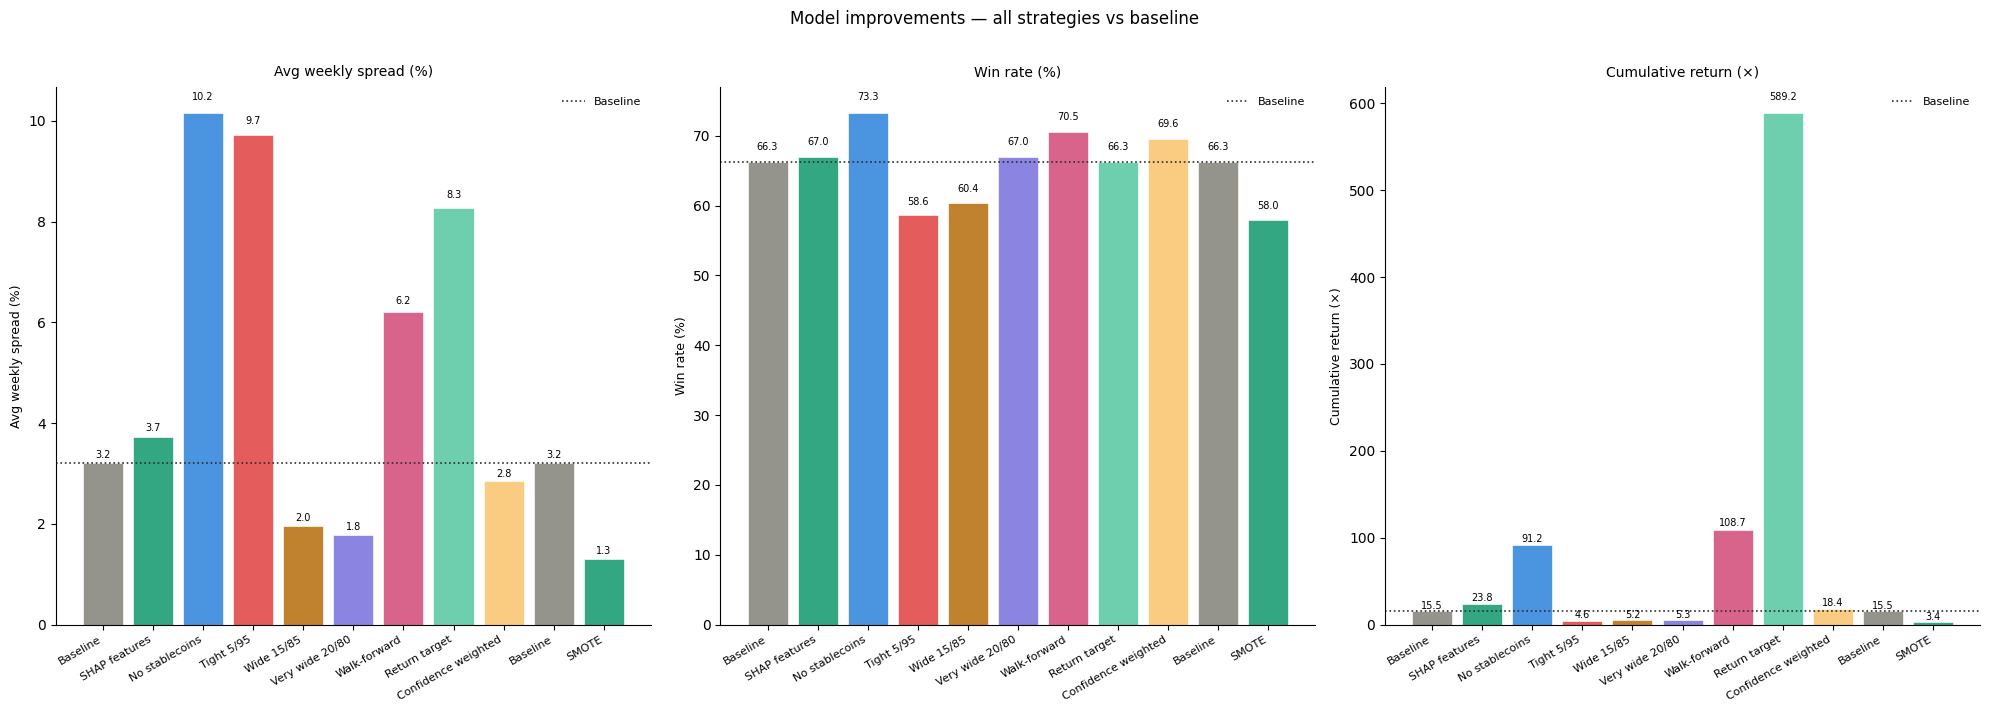

Saved -> model_improvements_comparison.png


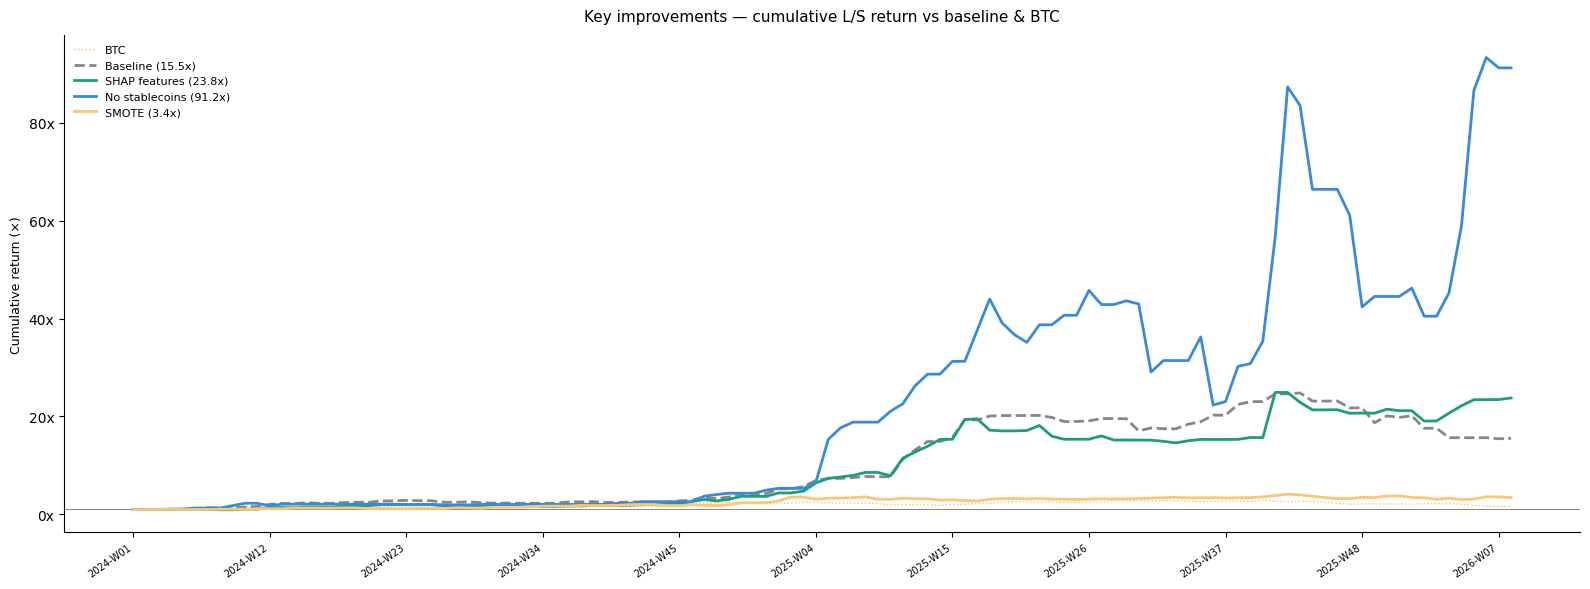

Saved -> model_improvements_cumret.png
Saved -> model_improvements_summary.csv


In [ ]:
summary = [{k:v for k,v in r.items() if k != '_pnl'} for r in ALL_RESULTS]
results_df = pd.DataFrame(summary)
results_df.to_csv(DYPLOM / 'model_improvements_summary.csv', index=False)

print('='*80)
print('MODEL IMPROVEMENTS SUMMARY')
print('='*80)
print(results_df[['Improvement','Accuracy (%)','Avg Spread (%)','Win Rate (%)','Cum Return (x)','Monotonic']].to_string(index=False))

palette = ['#888780','#1D9E75','#378ADD','#E24B4A','#BA7517','#7F77DD','#D4537E','#5DCAA5','#FAC775']
colors  = palette[:len(results_df)]
xlbls   = [r.split(' — ')[-1] if ' — ' in r else r for r in results_df['Improvement']]
x       = range(len(results_df))

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('white')
for ax, col, ylabel in [
    (axes[0], 'Avg Spread (%)', 'Avg weekly spread (%)'),
    (axes[1], 'Win Rate (%)',   'Win rate (%)'),
    (axes[2], 'Cum Return (x)','Cumulative return (×)'),
]:
    vals = results_df[col].tolist()
    bars = ax.bar(x, vals, color=colors, edgecolor='white', linewidth=0.5, alpha=0.9)
    ax.axhline(vals[0], color='#2C2C2A', lw=1.2, ls=':', label='Baseline')
    ax.axhline(0, color='#888780', lw=0.6)
    ax.set_xticks(x); ax.set_xticklabels(xlbls, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(ylabel, fontsize=10, fontweight='500', pad=8)
    ax.legend(fontsize=8, framealpha=0)
    ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')
    for bar, val in zip(bars, vals):
        off = max(abs(val)*0.02, 0.05) * (1 if val >= 0 else -1)
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+off,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Model improvements — all strategies vs baseline', fontsize=12, fontweight='500', y=1.01)
plt.tight_layout()
p = OUT_DIR / 'model_improvements_comparison.png'
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white'); plt.show()
print(f'Saved -> {p.name}')

# Cumulative return chart
wk_labels = sorted(test_base['year_week'].unique())
step = max(1, len(wk_labels)//10)
n    = len(wk_labels)
btc_cum = cumret(btc_w.reset_index(drop=True).iloc[:n])

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.plot(range(len(btc_cum)), btc_cum.values,
        color=BTC_COLOR, lw=1.0, ls=':', alpha=0.6, label='BTC')
ax.axhline(1.0, color='#888780', lw=0.7)

plot_idxs = [0, 1, 2, -1]
for idx in plot_idxs:
    r   = ALL_RESULTS[idx]
    pnl = r['_pnl']
    cum = cumret(pnl['net'])
    col = colors[idx % len(colors)]
    ls  = '--' if idx == 0 else '-'
    ax.plot(range(len(cum)), cum.values, color=col, lw=2.0, ls=ls,
            label=f"{r['Improvement'].split(' — ')[-1]} ({cum.values[-1]:.1f}x)")

ax.set_xticks(range(0, n, step))
ax.set_xticklabels(wk_labels[::step], rotation=35, ha='right', fontsize=7)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.0f}x'))
ax.set_ylabel('Cumulative return (×)', fontsize=9)
ax.set_title('Key improvements — cumulative L/S return vs baseline & BTC',
             fontsize=11, fontweight='500', pad=10)
ax.legend(fontsize=8, framealpha=0, loc='upper left')
ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')
plt.tight_layout()
p = OUT_DIR / 'model_improvements_cumret.png'
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white'); plt.show()
print(f'Saved -> {p.name}')
print('Saved -> model_improvements_summary.csv')